In [5]:
import torch
from torch import nn

In [6]:
#deep learning model
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = torch.relu(torch.max_pool2d(self.conv1(x), 2))
        x = torch.relu(torch.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

#define optimizer
net=Net()
optimizer=torch.optim.SGD(net.parameters(),lr=0.001,momentum=0.9)
loss_function=nn.CrossEntropyLoss()

#Defining the model and training
from secml.ml.classifiers import CClassifierPyTorch

clf=CClassifierPyTorch(model=net,
                       loss=loss_function,
                       optimizer=optimizer,
                       epochs=15,
                       batch_size=20,
                       input_shape=(1,28,28),
                       random_state=0)


In [32]:
%matplotlib inline
from secml.data.loader import CDataLoaderMNIST
from secml.ml.peval.metrics import CMetricAccuracy
from secml.figure import CFigure

def show_digits(samples, preds, labels, n_display=5):
    digits = list(range(10))
    n_display = min(n_display, samples.shape[0])
    fig = CFigure(width=n_display * 2, height=4)
    for idx in range(n_display):
        fig.subplot(2, n_display, idx + 1)
        fig.sp.xticks([])
        fig.sp.yticks([])
        fig.sp.imshow(samples[idx, :].reshape((28, 28)), cmap='gray')
        fig.sp.title("{} ({})".format(digits[labels[idx].item()], digits[preds[idx].item()]),
                     color=("green" if labels[idx].item() == preds[idx].item() else "red"))
    fig.show()


ACCURACY: 0.954


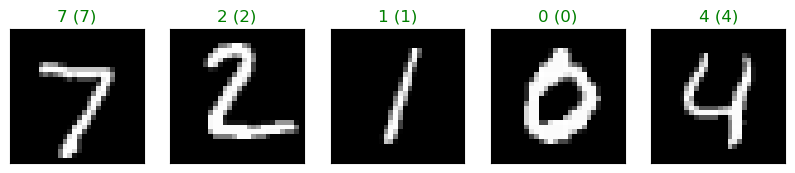

In [50]:
loader = CDataLoaderMNIST()
tr = loader.load('training', num_samples=2000)
ts = loader.load('testing', num_samples=500)
tr.X = tr.X / 255
ts.X = ts.X / 255

clf.fit(tr.X, tr.Y)
y_pred=clf.predict(ts.X)

metric = CMetricAccuracy()
clean_acc = metric.performance_score(y_true=ts.Y, y_pred=y_pred)

print(f"ACCURACY: {clean_acc}")
show_digits(ts.X, clf.predict(ts.X), ts.Y)


In [51]:
import time
from secml.adv.attacks.evasion.foolbox.fb_attacks.fb_fgm_attack import CFoolboxFGM

fgm = CFoolboxFGM(
    classifier = clf,
    epsilons = 0.2,
    lb = 0,
    ub = 1,
    distance = "linf",
    random_start = False
)

start = time.time()
_, _, adv_fgm, _= fgm.run(ts.X, ts.Y)
end = time.time()
y_pred = clf.predict(adv_fgm.X)

adv_acc_fgm = metric.performance_score(y_true=ts.Y, y_pred=y_pred)
print(f"DURATION: {end - start}s")
print(f"ACCURACY: {adv_acc_fgm}")


DURATION: 7.878310203552246s
ACCURACY: 0.072


In [52]:
from secml.adv.attacks.evasion.foolbox.fb_attacks.fb_pgd_attack import CFoolboxPGDLinf

pgd = CFoolboxPGDLinf(
    classifier = clf,
    epsilons = 0.2,
    rel_stepsize = 0.015,
    steps = 40
)

start = time.time()
_, _, adv_pgd, _= pgd.run(ts.X, ts.Y)
end = time.time()
y_pred =  clf.predict(adv_pgd.X)

adv_acc_pgd= metric.performance_score(y_true=ts.Y, y_pred=y_pred)
print(f"DURATION: {end - start}s")
print(f"ACCURACY: {accuracy}")


DURATION: 191.1066129207611s
ACCURACY: 0.274


CLEAN ACC: 95.39999999999999%
FGM ACC: 7.199999999999999%
PGD ACC: 22.8%
FGM SUCCESS: 92.80000000000001%
PGD SUCCESS: 77.2%



------------------
FGM ATTACKED BELOW


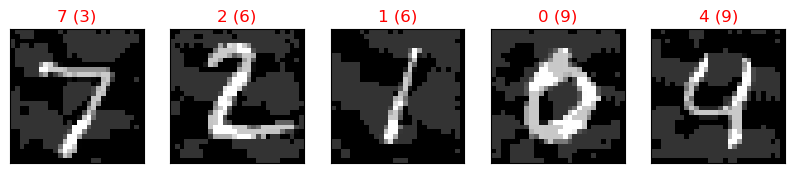

PGD ATTACKED BELOW


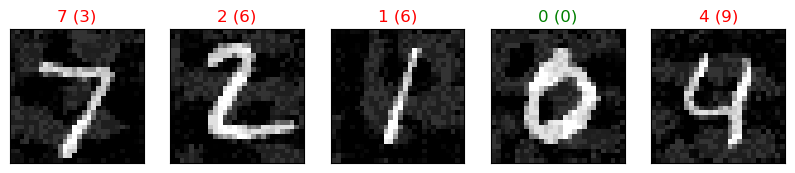

In [53]:
print(f"CLEAN ACC: {clean_acc*100}%")
print(f"FGM ACC: {adv_acc_fgm*100}%")
print(f"PGD ACC: {adv_acc_pgd*100}%")
print(f"FGM SUCCESS: {(1-adv_acc_fgm)*100}%")
print(f"PGD SUCCESS: {(1-adv_acc_pgd)*100}%")

print("\n\n\n------------------")
print("FGM ATTACKED BELOW")
show_digits(adv_fgm.X, clf.predict(adv_fgm.X), ts.Y)
print("PGD ATTACKED BELOW")
show_digits(adv_pgd.X, clf.predict(adv_pgd.X), ts.Y)


Attack Length: FGM attack on test set was 8s while PGD was around 3 minutes.

Attack Strength: FGM reduced to model acc to 7% while PGD was 27%.

Perceptibility: Both methods reveal that they are obviously altered but pgd is more pixelated while FGM is more smooth.

Runtime/Efficiency: FGM is just in everyway better. If the attack is this obvious it should be fast and efficient which FGM was, while PGD was considerably slower and less accurate.

Attack Success: I think the FGM succeeded because it was faster, made the model ineffective and possibly having the smoother alteration which may be less obvious than the grainy alterations of PGD.

Which would i choose: FGM for speed and reliability. None for stealth, the image alterations are way too obvious too humans, someone would detect it immediatley.
